Extracting Initial Information from CSV

In [ ]:
import pandas as pd 
import numpy as np


df = pd.read_csv("1976-2020-president.csv") 

# Convert candidatevotes to numeric (handles strings with commas)
df['candidatevotes'] = pd.to_numeric(df['candidatevotes'], errors='coerce')

# Drop rows with NaN candidatevotes
df = df.dropna(subset=['candidatevotes'])

# Ensure candidatevotes is numeric type (not object)
df['candidatevotes'] = df['candidatevotes'].astype('float64')

#Generating the Head (First 5 values of the dataset) 
df.head()

,year,state,state_po,state_fips,state_cen,state_ic,office,candidate,party_detailed,writein,candidatevotes,totalvotes,version,notes,party_simplified
0,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"CARTER, JIMMY",DEMOCRAT,False,659170.0,1182850,20210113,NaN,DEMOCRAT
1,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"FORD, GERALD",REPUBLICAN,False,504070.0,1182850,20210113,NaN,REPUBLICAN
2,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"MADDOX, LESTER",AMERICAN INDEPENDENT PARTY,False,9198.0,1182850,20210113,NaN,OTHER
3,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"BUBAR, BENJAMIN """"BEN""""",PROHIBITION,False,6669.0,1182850,20210113,NaN,OTHER
4,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"HALL, GUS",COMMUNIST PARTY USE,False,1954.0,1182850,20210113,NaN,OTHER


In [ ]:
#Generating the Dataframe shape 
df.shape

(4287, 15)

In [ ]:
#Determining how many columns contain NaN information 
for column in df.columns: 
    print(f"{column}: {df[column].isnull().sum()}") 


#Dropping columns that exist and are all null 
columns_to_drop = [col for col in ['notes', 'party_simplified'] if col in df.columns]
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)  

#Grouping Entries by State and Party 
dist_per_party_and_state=df.groupby(['state','party_detailed'])['candidatevotes'].sum().sort_values(ascending=False)
print(dist_per_party_and_state) 

#We are grouping by Party_detailed due to the more encompassing nature of the party declaration

year: 0
state: 0
state_po: 0
state_fips: 0
state_cen: 0
state_ic: 0
office: 0
candidate: 287
party_detailed: 456
writein: 3
candidatevotes: 0
totalvotes: 0
version: 0
notes: 4287
party_simplified: 0
state          party_detailed
CALIFORNIA     DEMOCRAT          74290623.0
               REPUBLICAN        56805352.0
NEW YORK       DEMOCRAT          45929137.0
TEXAS          REPUBLICAN        44117621.0
FLORIDA        REPUBLICAN        38656563.0
                                    ...    
MASSACHUSETTS  PROHIBITION              2.0
NEW YORK       SOCIALIST                2.0
ARIZONA        WORKERS WORLD            2.0
DELAWARE       NON-AFFILIATED           2.0
INDIANA        NON-AFFILIATED           1.0
Name: candidatevotes, Length: 1102, dtype: float64


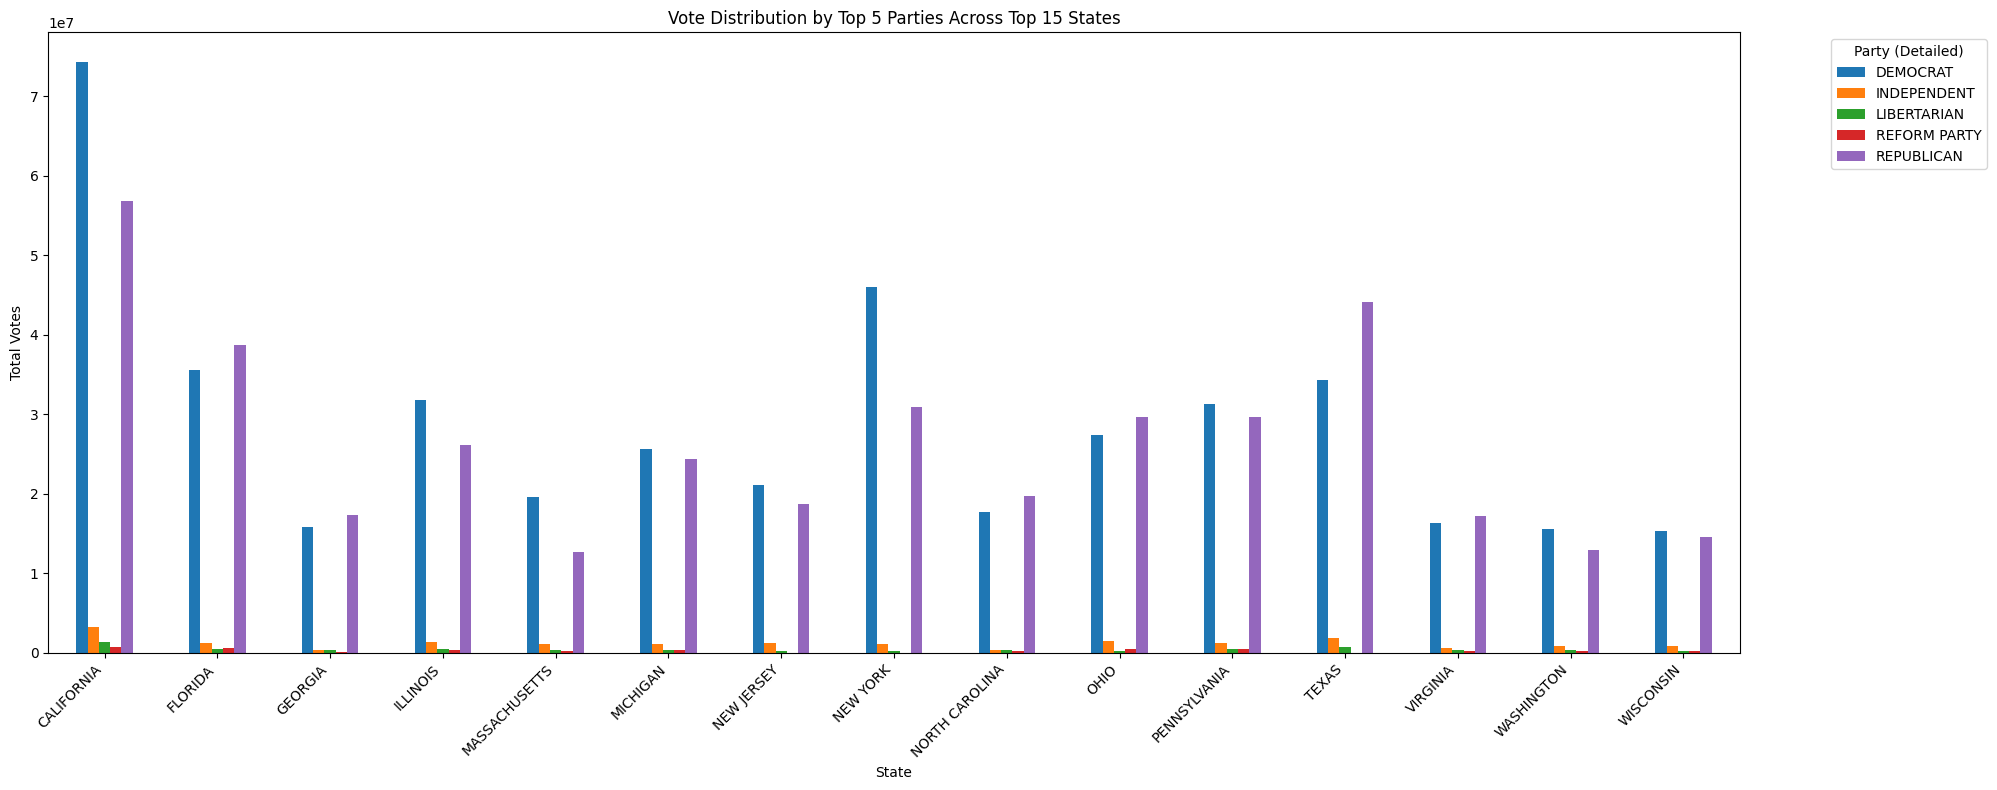

In [ ]:
# Get the top 5 parties nationwide
import matplotlib.pyplot as plt
import geopandas as gpd

# Get top 15 states by total votes
top_states = df.groupby('state')['candidatevotes'].sum().nlargest(15).index
df_top_states = df[df['state'].isin(top_states)]

top_parties = df_top_states.groupby('party_detailed')['candidatevotes'].sum().nlargest(5).index
filtered_df = df_top_states[df_top_states['party_detailed'].isin(top_parties)]

# Create grouped bar chart for top 15 states
state_party_votes = filtered_df.groupby(['state', 'party_detailed'])['candidatevotes'].sum().unstack(fill_value=0)
state_party_votes.plot(kind='bar', figsize=(20, 8))
plt.title('Vote Distribution by Top 5 Parties Across Top 15 States')
plt.xlabel('State')
plt.ylabel('Total Votes')
plt.legend(title='Party (Detailed)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:

# Option 3: Interactive Plotly visualization (requires plotly)
import plotly.express as px
# Prepare data for interactive visualization
state_party_data = df.groupby(['state', 'party_detailed'])['candidatevotes'].sum().reset_index()
# Create interactive bar chart
fig = px.bar(state_party_data, 
             x='state', 
             y='candidatevotes',
             color='party_detailed',
             title='Votes by State and Party (Detailed)',
             labels={'candidatevotes': 'Total Votes', 'state': 'State'},
             height=600)
fig.show()


In [ ]:
# Merging the disaster_data with the election data to see how partisan voting patterns may have been influenced by natural disasters and FEMA aid distribution. 

df_disasters = pd.read_csv("disaster_data_export.csv") 

# ===== CLEANING THE DISASTER DATA =====

# 1. Convert date columns to datetime
date_columns = ['incident_start', 'incident_end', 'declaration_date']
for col in date_columns:
    df_disasters[col] = pd.to_datetime(df_disasters[col], errors='coerce')

# 2. Handle state name standardization
df_disasters['state'] = df_disasters['state'].str.strip().str.title()
print(f"Unique states in disaster data: {df_disasters['state'].nunique()}")
print(f"Sample states: {df_disasters['state'].unique()[:5]}")

# 3. Aggregate disaster data by state and year (since multiple disasters can occur per state-year)
disaster_summary = df_disasters.groupby(['year', 'state']).agg({
    'incident_number': 'count',  # Count of disasters
    'ihp_total': 'sum',  # Total individual assistance
    'pa_total': 'sum',  # Total public assistance
    'cdbg_dr_allocation': 'sum',  # Community development block grants
    'sba_total_approved_loan_amount': 'sum',  # SBA loans
    'valid_ihp_applications': 'sum',
    'incident_type': lambda x: ', '.join(x.dropna().unique()),  # Concatenate incident types
}).reset_index()

# Rename the count column for clarity
disaster_summary.rename(columns={'incident_number': 'disaster_count'}, inplace=True)

# 4. Fill NaN values with 0 for monetary columns (NaN means no aid was provided)
monetary_cols = ['ihp_total', 'pa_total', 'cdbg_dr_allocation', 'sba_total_approved_loan_amount', 'valid_ihp_applications']
for col in monetary_cols:
    disaster_summary[col] = disaster_summary[col].fillna(0)

# 5. Create a total aid column
disaster_summary['total_fema_aid'] = (disaster_summary['ihp_total'] + 
                                       disaster_summary['pa_total'] + 
                                       disaster_summary['cdbg_dr_allocation'] + 
                                       disaster_summary['sba_total_approved_loan_amount'])

print("\nCleaned Disaster Summary:")
print(disaster_summary.head())
print(f"\nDisaster Summary shape: {disaster_summary.shape}")


Unique states in disaster data: 56
Sample states: <StringArray>
['Alaska', 'Wisconsin', 'South Dakota', 'New Mexico', 'Missouri']
Length: 5, dtype: str

Cleaned Disaster Summary:
   year       state  disaster_count    ihp_total      pa_total  \
0  2015     Alabama               1         0.00  3.620189e+07   
1  2015      Alaska               2         0.00  1.554366e+07   
2  2015    Arkansas               2   2369547.26  1.968390e+07   
3  2015  California               1  12733883.73  2.220142e+08   
4  2015    Colorado               1         0.00  2.472314e+07   

   cdbg_dr_allocation  sba_total_approved_loan_amount  valid_ihp_applications  \
0                 0.0                               0                     0.0   
1                 0.0                               0                     0.0   
2                 0.0                               0                  1230.0   
3                 0.0                         6566600                  3716.0   
4                 0

C:\Users\jakef\AppData\Local\Temp\ipykernel_36488\1072296656.py:10: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\jakef\AppData\Local\Temp\ipykernel_36488\1072296656.py:10: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\jakef\AppData\Local\Temp\ipykernel_36488\1072296656.py:10: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [ ]:
# ===== MERGING AND PREPARING DATA FOR VISUALIZATION =====

# 1. Standardize state names in election data to match disaster data (Title Case)
df['state'] = df['state'].str.strip().str.title()

# 2. For each state-year, determine the winning party
election_by_state_year = df.groupby(['year', 'state']).apply(
    lambda x: x.loc[x['candidatevotes'].idxmax(), 'party_detailed']
).reset_index()
election_by_state_year.columns = ['year', 'state', 'winning_party']

# 3. Also get total votes per state-year for context
votes_by_state_year = df.groupby(['year', 'state'])['candidatevotes'].sum().reset_index()
votes_by_state_year.rename(columns={'candidatevotes': 'total_votes'}, inplace=True)
election_by_state_year = election_by_state_year.merge(votes_by_state_year, on=['year', 'state'])

# 4. Merge election results with disaster data
merged_df = election_by_state_year.merge(
    disaster_summary, 
    on=['year', 'state'], 
    how='left'
)

# 5. Fill NaN values for states with no disasters
merged_df['disaster_count'] = merged_df['disaster_count'].fillna(0)
merged_df['total_fema_aid'] = merged_df['total_fema_aid'].fillna(0)
merged_df['incident_type'] = merged_df['incident_type'].fillna('No reported disasters')

# 6. Create a formatted total aid column for display
merged_df['total_fema_aid_formatted'] = '$' + (merged_df['total_fema_aid'] / 1e6).round(2).astype(str) + 'M'

print("Merged Dataset:")
print(merged_df.head(10))
print(f"\nMerged Dataset shape: {merged_df.shape}")
print(f"\nStates with no disaster records: {merged_df[merged_df['disaster_count'] == 0].shape[0]} state-year combinations")


Merged Dataset:
   year                 state winning_party  total_votes  disaster_count  \
0  1976               Alabama      DEMOCRAT    1182850.0             0.0   
1  1976                Alaska    REPUBLICAN     123574.0             0.0   
2  1976               Arizona    REPUBLICAN     742719.0             0.0   
3  1976              Arkansas      DEMOCRAT     767535.0             0.0   
4  1976            California    REPUBLICAN    7803770.0             0.0   
5  1976              Colorado    REPUBLICAN    1081440.0             0.0   
6  1976           Connecticut    REPUBLICAN    1386355.0             0.0   
7  1976              Delaware      DEMOCRAT     235642.0             0.0   
8  1976  District Of Columbia      DEMOCRAT     168830.0             0.0   
9  1976               Florida      DEMOCRAT    3150631.0             0.0   

   ihp_total  pa_total  cdbg_dr_allocation  sba_total_approved_loan_amount  \
0        NaN       NaN                 NaN                           

In [ ]:
# ===== INTERACTIVE PLOTLY VISUALIZATION =====

import plotly.graph_objects as go

# Define color mapping for parties
party_colors = {
    'DEMOCRAT': '#1f77b4',
    'REPUBLICAN': '#d62728',
    'LIBERTARIAN': '#ff7f0e',
    'GREEN': '#2ca02c',
    'OTHER': '#9467bd'
}

# Get all unique years and sort them
election_years = sorted(merged_df['year'].unique())

# Create frames for animation (one per year)
frames = []
for year in election_years:
    year_data = merged_df[merged_df['year'] == year]
    
    # Create hover text with detailed information
    hover_text = (
        '<b>' + year_data['state'] + '</b><br>' +
        'Winning Party: ' + year_data['winning_party'] + '<br>' +
        'Total Votes: ' + (year_data['total_votes']/1000).round(1).astype(str) + 'K<br>' +
        'Disasters: ' + year_data['disaster_count'].astype(int).astype(str) + '<br>' +
        'Incident Types: ' + year_data['incident_type'] + '<br>' +
        'Total FEMA Aid: ' + year_data['total_fema_aid_formatted'] +
        '<extra></extra>'
    )
    
    # Assign colors based on winning party
    bar_colors = year_data['winning_party'].map(party_colors).fillna('#cccccc')
    
    fig_data = go.Bar(
        x=year_data['state'],
        y=year_data['total_votes'],
        marker=dict(color=bar_colors, line=dict(color='darkgray', width=1)),
        hovertext=hover_text,
        hoverinfo='text',
        name='Election Results'
    )
    
    frames.append(go.Frame(data=[fig_data], name=str(year)))

# Create initial figure with first year
initial_year = election_years[0]
initial_data = merged_df[merged_df['year'] == initial_year]
initial_colors = initial_data['winning_party'].map(party_colors).fillna('#cccccc')
initial_hover = (
    '<b>' + initial_data['state'] + '</b><br>' +
    'Winning Party: ' + initial_data['winning_party'] + '<br>' +
    'Total Votes: ' + (initial_data['total_votes']/1000).round(1).astype(str) + 'K<br>' +
    'Disasters: ' + initial_data['disaster_count'].astype(int).astype(str) + '<br>' +
    'Incident Types: ' + initial_data['incident_type'] + '<br>' +
    'Total FEMA Aid: ' + initial_data['total_fema_aid_formatted'] +
    '<extra></extra>'
)

fig = go.Figure(
    data=[go.Bar(
        x=initial_data['state'],
        y=initial_data['total_votes'],
        marker=dict(color=initial_colors, line=dict(color='darkgray', width=1)),
        hovertext=initial_hover,
        hoverinfo='text'
    )],
    frames=frames
)

# Add legend elements
legend_elements = [
    go.Scatter(x=[None], y=[None], mode='markers', 
               marker=dict(size=10, color=color), name=party)
    for party, color in party_colors.items()
]

for element in legend_elements:
    fig.add_trace(element)

# Update layout with animation controls
fig.update_layout(
    title=dict(text=f'US Presidential Election Results by State with Disaster Data ({initial_year})',
               font=dict(size=16)),
    xaxis_title='State',
    yaxis_title='Total Votes',
    height=700,
    hovermode='closest',
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        y=1.15,
        x=0.0,
        xanchor='left',
        yanchor='top',
        buttons=[
            dict(label='▶ Play', method='animate',
                 args=[None, {'frame': {'duration': 500, 'redraw': True},
                               'fromcurrent': True, 'transition': {'duration': 300}}]),
            dict(label='⏸ Pause', method='animate',
                 args=[[None], {'frame': {'duration': 0, 'redraw': True},
                                 'mode': 'immediate', 'transition': {'duration': 0}}])
        ]
    )],
    sliders=[{
        'active': 0,
        'yanchor': 'top',
        'y': -0.15,
        'xanchor': 'left',
        'x': 0.0,
        'len': 0.9,
        'transition': {'duration': 300},
        'pad': {'b': 10, 't': 50},
        'currentvalue': {
            'font': {'size': 12},
            'prefix': 'Year: ',
            'visible': True,
            'xanchor': 'center'
        },
        'steps': [
            {
                'args': [[str(year)], {
                    'frame': {'duration': 300, 'redraw': True},
                    'mode': 'immediate',
                    'transition': {'duration': 300}
                }],
                'method': 'animate',
                'label': str(year)
            }
            for year in election_years
        ]
    }]
)

fig.show()


In [ ]:
# Elections following natural disasters

import plotly.graph_objects as go
from datetime import timedelta

# Create a detailed disaster timeline with election years
df_disasters_with_dates = df_disasters.copy()
df_disasters_with_dates['state'] = df_disasters_with_dates['state'].str.strip().str.title()

# Get election years
election_years_set = set(df['year'].unique())

# For each election year, find disasters that occurred within 24 months BEFORE the election
# This captures the effects leading up to the election 

def find_disasters_before_election(state_name, election_year, months_lookback=24):
    """Find disasters within X months before an election"""
    election_disasters = df_disasters_with_dates[
        (df_disasters_with_dates['state'] == state_name) &
        (df_disasters_with_dates['year'] >= election_year - 2) &
        (df_disasters_with_dates['year'] <= election_year)
    ].copy()
    return election_disasters

# Create a comprehensive list of elections with preceding disasters
elections_with_disasters = []

for state in merged_df['state'].unique():
    for year in election_years_set:
        election_record = merged_df[(merged_df['state'] == state) & (merged_df['year'] == year)]
        
        if len(election_record) > 0:
            disasters_before = find_disasters_before_election(state, year)
            
            if len(disasters_before) > 0:  # Only include if there were disasters
                elections_with_disasters.append({
                    'state': state,
                    'election_year': year,
                    'winning_party': election_record['winning_party'].values[0],
                    'total_votes': election_record['total_votes'].values[0],
                    'disaster_count': len(disasters_before),
                    'disaster_types': ', '.join(disasters_before['incident_type'].unique()),
                    'fema_aid_24mo': disasters_before['pa_total'].sum() + disasters_before['ihp_total'].sum(),
                    'first_disaster_year': disasters_before['year'].min(),
                    'last_disaster_year': disasters_before['year'].max()
                })

# Convert to DataFrame for easier analysis
elections_disaster_df = pd.DataFrame(elections_with_disasters)
elections_disaster_df['fema_aid_formatted'] = '$' + (elections_disaster_df['fema_aid_24mo'] / 1e6).round(2).astype(str) + 'M'
elections_disaster_df = elections_disaster_df.sort_values(['election_year', 'fema_aid_24mo'], ascending=[False, False])

print(f"Elections following natural disasters (within 24 months): {len(elections_disaster_df)}")
print(f"\nSample of Elections After Disasters:")
print(elections_disaster_df[['state', 'election_year', 'winning_party', 'disaster_count', 'fema_aid_formatted']].head(15))

# Create US state codes mapping
state_codes = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# VISUALIZATION: Scatter plot comparing FEMA aid vs voting patterns for elections after disasters
party_colors = {
    'DEMOCRAT': '#1f77b4',
    'REPUBLICAN': '#d62728',
    'LIBERTARIAN': '#ff7f0e',
    'GREEN': '#2ca02c',
    'OTHER': '#9467bd'
}

elections_disaster_df['color'] = elections_disaster_df['winning_party'].map(party_colors)
elections_disaster_df['state_code'] = elections_disaster_df['state'].map(state_codes)

fig = go.Figure()

# Add scatter points for each party
for party in party_colors.keys():
    party_data = elections_disaster_df[elections_disaster_df['winning_party'] == party]
    
    hover_text = (
        '<b>' + party_data['state'] + ' (' + party_data['election_year'].astype(str) + ')</b><br>' +
        'Winning Party: ' + party_data['winning_party'] + '<br>' +
        'Total Votes: ' + (party_data['total_votes']/1e6).round(2).astype(str) + 'M<br>' +
        'Disasters (24mo prior): ' + party_data['disaster_count'].astype(int).astype(str) + '<br>' +
        'Disaster Types: ' + party_data['disaster_types'] + '<br>' +
        'FEMA Aid (24mo): ' + party_data['fema_aid_formatted']
    )
    
    fig.add_trace(go.Scatter(
        x=party_data['fema_aid_24mo'],
        y=party_data['total_votes'],
        mode='markers',
        name=party,
        marker=dict(size=10, color=party_colors[party], opacity=0.7, line=dict(width=1, color='darkgray')),
        text=hover_text,
        hovertemplate='%{text}<extra></extra>'
    ))

fig.update_layout(
    title='Elections Following Natural Disasters (within 24 months)<br><sub>X-axis: FEMA Aid | Y-axis: Total Votes</sub>',
    xaxis_title='Total FEMA Aid Provided (24 months prior to election) ($)',
    yaxis_title='Total Votes Cast',
    height=600,
    hovermode='closest',
    xaxis_type='log'  # Log scale to better visualize wide range of aid amounts
)

fig.show()

# CHOROPLETH: Show elections after disasters for a specific recent election year
latest_election_year = elections_disaster_df['election_year'].max()
latest_year_disasters = elections_disaster_df[elections_disaster_df['election_year'] == latest_election_year].copy()

if len(latest_year_disasters) > 0:
    latest_year_disasters['state_code'] = latest_year_disasters['state'].map(state_codes)
    
    hover_text_map = (
        '<b>' + latest_year_disasters['state'] + '</b><br>' +
        'Winning Party: ' + latest_year_disasters['winning_party'] + '<br>' +
        'Total Votes: ' + (latest_year_disasters['total_votes']/1e6).round(2).astype(str) + 'M<br>' +
        'Disasters (24mo): ' + latest_year_disasters['disaster_count'].astype(int).astype(str) + '<br>' +
        'Disaster Types: ' + latest_year_disasters['disaster_types'] + '<br>' +
        'FEMA Aid: ' + latest_year_disasters['fema_aid_formatted']
    )
    
    fig_map = go.Figure(data=go.Choropleth(
        locations=latest_year_disasters['state_code'],
        z=latest_year_disasters['fema_aid_24mo'],
        text=hover_text_map,
        hovertemplate='%{text}<extra></extra>',
        colorscale=[
            [0, '#fff7bc'],
            [1, '#e74c3c']
        ],
        marker_line_color='darkgray',
        colorbar=dict(title='FEMA Aid<br>($)', thickness=20, len=0.7)
    ))


Elections following natural disasters (within 24 months): 87

Sample of Elections After Disasters:
             state  election_year winning_party  disaster_count  \
33       Louisiana           2020    REPUBLICAN               6   
8       California           2020      DEMOCRAT               9   
17         Florida           2020    REPUBLICAN               3   
57  North Carolina           2020    REPUBLICAN               7   
55        New York           2020      DEMOCRAT               3   
63          Oregon           2020      DEMOCRAT               4   
1          Alabama           2020    REPUBLICAN               9   
50        Nebraska           2020    REPUBLICAN               4   
27            Iowa           2020    REPUBLICAN               6   
61        Oklahoma           2020    REPUBLICAN               5   
44     Mississippi           2020    REPUBLICAN               9   
3           Alaska           2020    REPUBLICAN               2   
72       Tennessee           2